**Examen de certificación – Intento 2**

Contexto y Descripción del Dataset

El «Bank Marketing Dataset» contiene datos relacionados con campañas de marketing directo (llamadas telefónicas) de una institución bancaria portuguesa. La tarea es predecir si el cliente suscribirá un depósito a plazo (variable y).



In [25]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from scipy.stats import shapiro
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', None)

# Carga del dataset (en el examen se baja desde Kaggle, aca lo cargo del CSV)
df = pd.read_csv('/content/bank-full.csv',sep=';')
print(df.shape)
print(df.columns.tolist())

(45211, 17)
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [26]:
display(df.head())
display(df.tail())
df.info()
display(df.describe())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


**1. Limpieza de Datos:**

**1.1. Identificación y eliminación de valores duplicados:** Asegúrate de que no haya registros duplicados que puedan sesgar los resultados del análisis.

**1.2. Verificación y ajuste de tipos de datos:** Verifica que cada columna tenga el tipo de dato correcto (numérico o categórico) y ajusta si es necesario.

**1.3. Corrección de inconsistencias en valores categóricos:** Revisa las categorías de las variables y unifica aquellos valores que puedan estar escritos de diferentes maneras pero que representen lo mismo.

**1.4. Manejo de valores faltantes adecuadamente:** Identifica y maneja los valores faltantes utilizando técnicas apropiadas como la imputación de la mediana, media o moda, según corresponda.

In [27]:
# 1.1. Identificación y eliminación de valores duplicados.
duplicados = df.duplicated().sum()

print("Duplicados:", duplicados)
print("Porcentaje:", round(duplicados/len(df)*100,4), "%")

Duplicados: 0
Porcentaje: 0.0 %


No se identificaron registros duplicados en el dataset, por lo que no fue necesario eliminar observaciones. Esto asegura que los análisis y modelos posteriores no estarán sesgados por datos repetidos.

**1.2. Verificación y ajuste de tipos de datos.**

Se verificaron los tipos de datos mediante df.info(). El dataset contiene 7 variables numéricas (age, balance, day, duration, campaign, pdays y previous) almacenadas como int64, y 10 variables categóricas almacenadas como object. Tras la revisión, se concluyó que los tipos de datos son consistentes con la naturaleza de cada variable, por lo que no fue necesario realizar conversiones adicionales.

In [28]:
# 1.3. Corrección de inconsistencias en valores categóricos.
categoricas=df.select_dtypes(include='object').columns

for col in categoricas:
    print(f"\n{col}")
    print(df[col].value_counts())


job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

default
default
no     44396
yes      815
Name: count, dtype: int64

housing
housing
yes    25130
no     20081
Name: count, dtype: int64

loan
loan
no     37967
yes     7244
Name: count, dtype: int64

contact
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count

In [29]:
for col in categoricas:df[col]=df[col].str.lower().str.strip()

No existen problemas de mayúsculas/minúsculas.

No existen categorías duplicadas con distinta escritura.

La principal inconsistencia corresponde a "unknown".

Se identificaron valores "unknown" en algunas variables categóricas, los cuales representan información no registrada o desconocida. Estos valores fueron tratados como datos faltantes para permitir una imputación adecuada.

In [30]:
# 1.4. Manejo de valores faltantes adecuadamente.
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [31]:
for col in categoricas:
    print(col,(df[col]=='unknown').sum())

job 288
marital 0
education 1857
default 0
housing 0
loan 0
contact 13020
month 0
poutcome 36959
y 0


In [34]:
df.replace('unknown', np.nan, inplace=True)

In [35]:
df.isnull().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day,0


In [36]:
for col in df.select_dtypes(include='object').columns:df[col].fillna(df[col].mode()[0],inplace=True)

In [37]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [38]:
for col in categoricas:
    print(col,(df[col]=='unknown').sum())

job 0
marital 0
education 0
default 0
housing 0
loan 0
contact 0
month 0
poutcome 0
y 0


Los valores "unknown" fueron reemplazados por valores nulos y posteriormente imputados utilizando la moda de cada variable categórica. Tras el proceso de imputación no quedaron valores faltantes en el conjunto de datos, garantizando la integridad de la información para las etapas posteriores de análisis y modelado.

La variable poutcome presenta una alta proporción de valores desconocidos (más del 80% de los registros). Aunque se realizó imputación para mantener la consistencia del conjunto de datos, esta variable podría aportar información limitada al modelo debido a la gran cantidad de información faltante originalmente.

**2. Exploración de Datos:**

**2.1. Visualizaciones univariadas y multivariadas:** Crea histogramas, gráficos de barras, diagramas de dispersión y mapas de calor para entender la distribución y las relaciones entre las variables.

**2.2. Estadísticas descriptivas:** Calcula medidas de tendencia central (media, mediana, moda) y de dispersión (rango, desviación estándar) para cada característica del dataset.

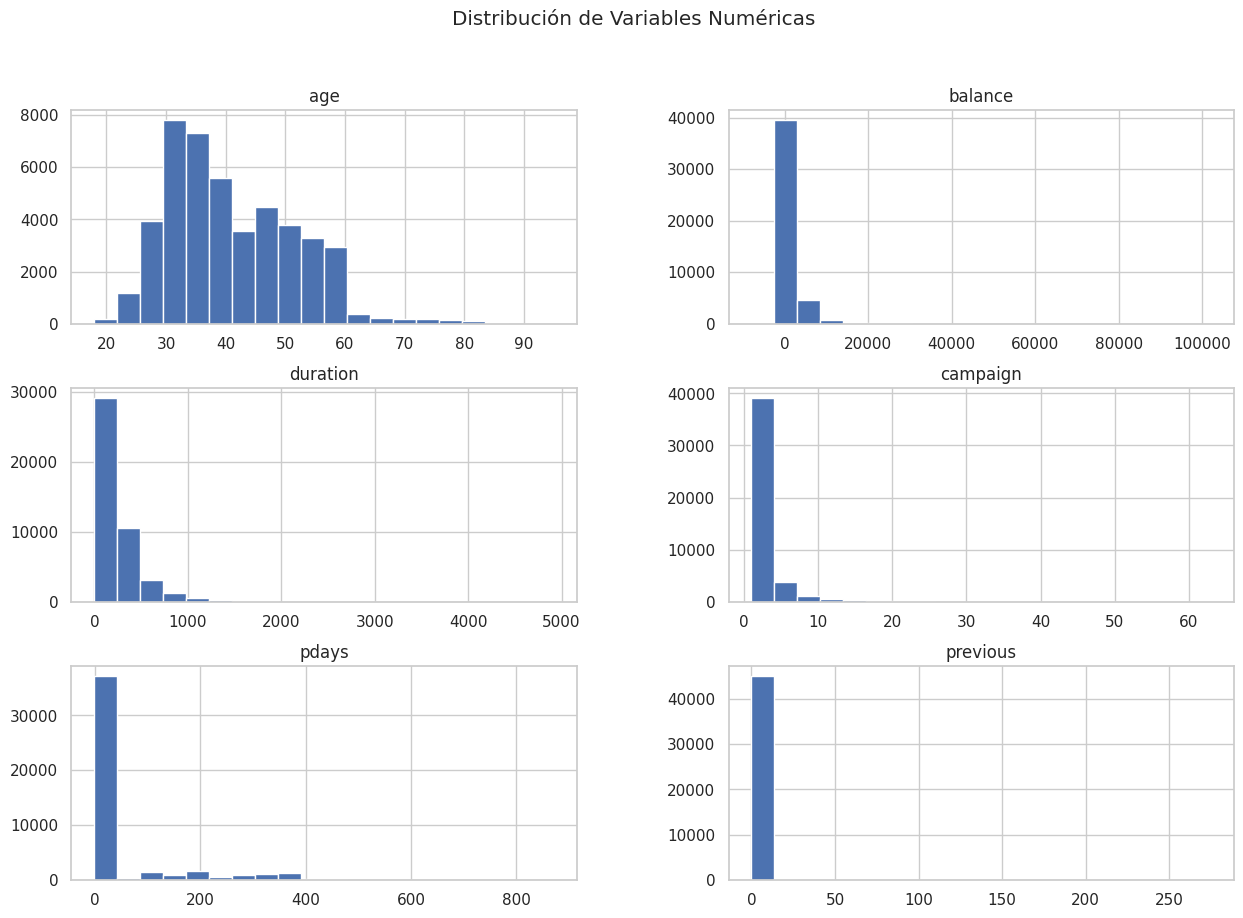

In [89]:
# 2.1. Visualizaciones univariadas y multivariadas.

# Histograma de variables numéricas
numericas=['age','balance','duration','campaign','pdays','previous']
df[numericas].hist(figsize=(15,10),bins=20)
plt.suptitle('Distribución de Variables Numéricas')
plt.show()

**Distribución de Variables Numéricas**

**Edad (age)**

La mayoría de los clientes se concentra entre los 30 y 50 años.

La distribución presenta una ligera asimetría positiva.

Existen pocos clientes mayores de 70 años.

La población objetivo del banco está compuesta principalmente por adultos en edad laboral activa, concentrados entre los 30 y 50 años.

**Balance (balance)**

La distribución presenta una fuerte asimetría positiva.

La mayoría de los clientes posee balances relativamente bajos.

Existen valores extremadamente altos que generan una larga cola derecha.

El balance bancario muestra una alta dispersión y presencia de valores extremos, indicando que un pequeño grupo de clientes concentra grandes saldos.

**Duración de la llamada (duration)**

La mayoría de las llamadas dura menos de 500 segundos.

Existen algunos contactos excepcionalmente largos.

La duración de las llamadas presenta una distribución sesgada hacia la derecha, con pocos casos de llamadas muy extensas.

**Campaign**

La mayoría de los clientes fue contactada entre 1 y 3 veces.

Pocos clientes recibieron más de 10 contactos.

El número de contactos durante la campaña se mantiene bajo para la mayoría de los clientes.

**Pdays**

Gran concentración de registros en valores bajos.

Presencia de valores extremos.

La variable presenta una distribución altamente asimétrica y evidencia diferencias importantes en el historial de contacto previo.

**Previous**

La mayoría de los clientes no había sido contactada anteriormente.

Existen pocos casos con múltiples contactos previos.

El historial de campañas previas es limitado para la mayor parte de los clientes.

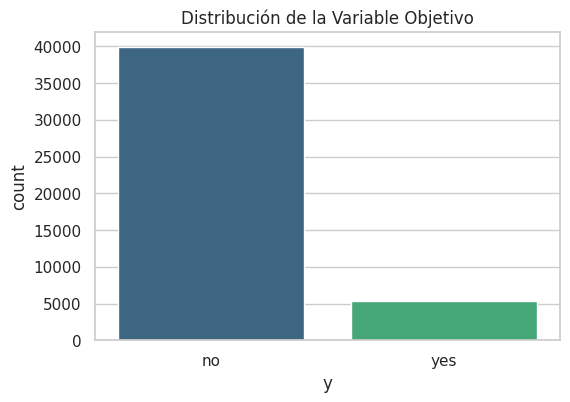

In [87]:
# Gráfico de barras para variables categóricas.
# Variable objetivo
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='y',palette='viridis')
plt.title('Distribución de la Variable Objetivo')
plt.show()

**Distribución de la Variable Objetivo**

Suscripción al Depósito (y)

No: aproximadamente 40.000 registros.

Sí: aproximadamente 5.000 registros.

Existe un importante desbalance de clases. La mayoría de los clientes no suscribió el depósito a plazo, por lo que será necesario considerar métricas adicionales a la exactitud durante la evaluación de los modelos.

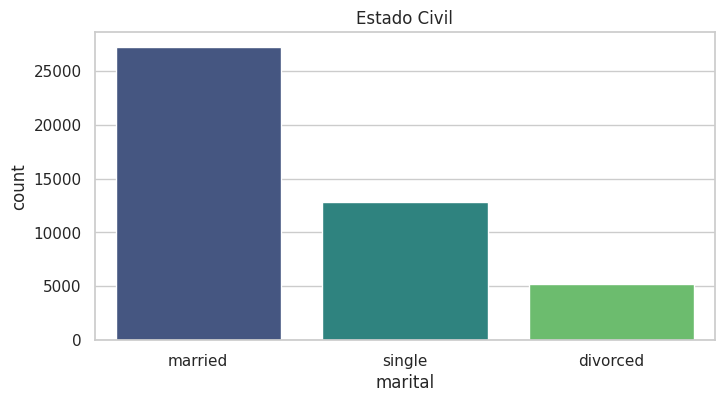

In [86]:
# Estado civil
plt.figure(figsize=(8,4))
sns.countplot(data=df,x='marital',palette='viridis')
plt.title('Estado Civil')
plt.show()

**Estado Civil**

Married es la categoría predominante.

Luego aparecen Single y Divorced.

La mayoría de los clientes se encuentra casada, lo que podría influir en decisiones financieras y comportamiento frente a productos bancarios.

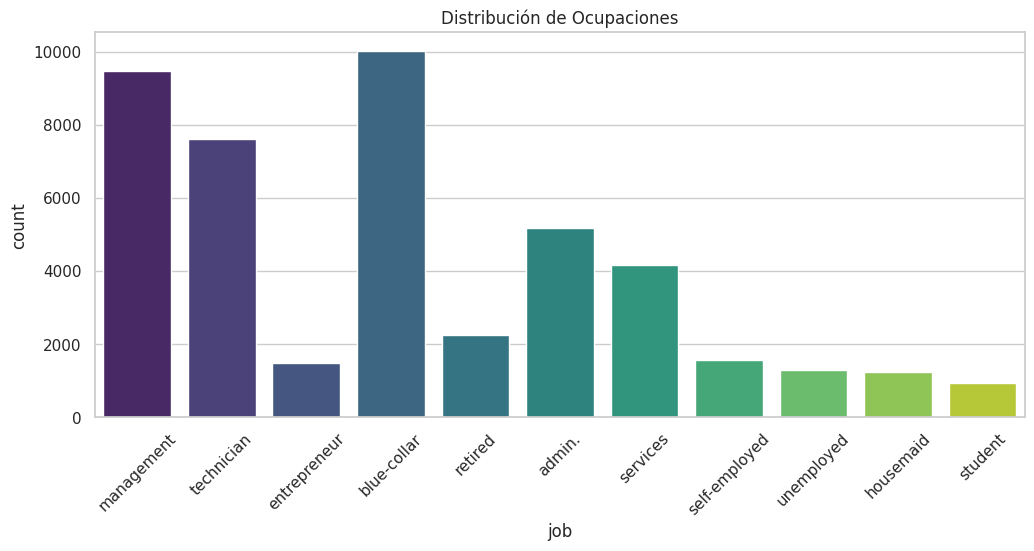

In [85]:
# Trabajo
plt.figure(figsize=(12,5))
sns.countplot(data=df,x='job',palette='viridis')
plt.xticks(rotation=45)
plt.title('Distribución de Ocupaciones')
plt.show()

**Ocupación (Job)**

Las ocupaciones más frecuentes son Blue-collar, Management, Technician.

Las menos frecuentes son Student, Housemaid, Unemployed.

El banco posee una cartera diversa de clientes, aunque predominan ocupaciones técnicas, administrativas y de gestión.

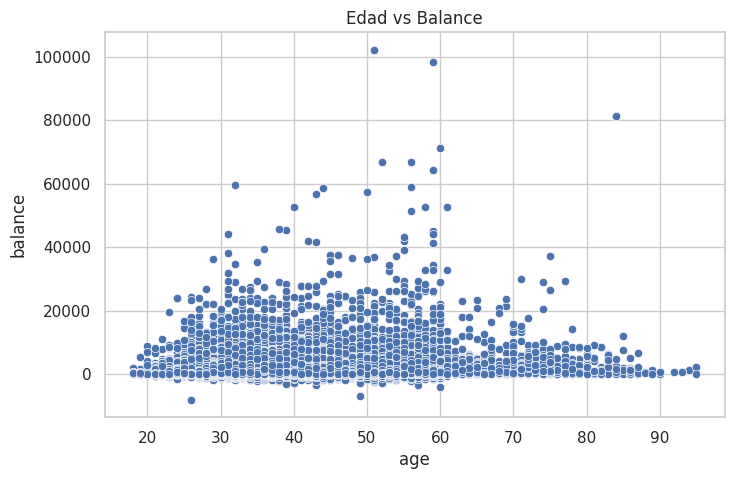

In [90]:
# Diagramas de dispersión
# Relación entre edad y balance
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='age',y='balance')
plt.title('Edad vs Balance')
plt.show()

**Diagramas de Dispersión**

**Edad vs Balance**

No se aprecia una relación lineal clara.

Existen clientes con balances altos en distintos rangos de edad.

Se observan numerosos outliers.

La edad por sí sola no parece explicar el comportamiento del balance bancario.

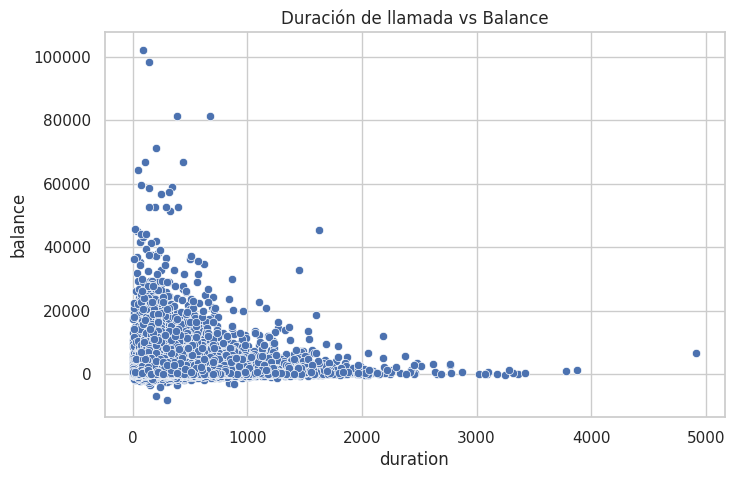

In [48]:
# Relación entre duración de llamada y balance
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='duration',y='balance')
plt.title('Duración de llamada vs Balance')
plt.show()

**Duración de la llamada vs Balance**

No existe una correlación visual evidente.

Los balances altos aparecen en distintos niveles de duración.

La duración de la llamada y el balance muestran una relación débil, por lo que ambas variables podrían aportar información independiente al modelo.

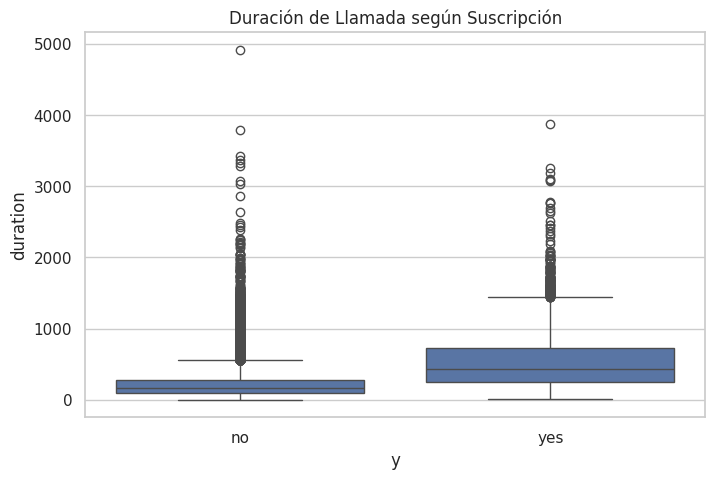

In [100]:
# Visualización multivariada
# Duración de llamada según suscripción
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='y',y='duration')
plt.title('Duración de Llamada según Suscripción')
plt.show()

**Boxplot: Duración según Suscripción**

Los clientes que suscribieron el depósito (yes) presentan una mediana de duración considerablemente mayor.

La separación entre ambas distribuciones es evidente.

La duración de la llamada parece ser una de las variables más relevantes para predecir la suscripción al depósito. Los clientes que aceptan el producto suelen mantener conversaciones más largas con el banco.

In [50]:
# Mapa de calor (Heatmap)
corr = df[numericas].corr()

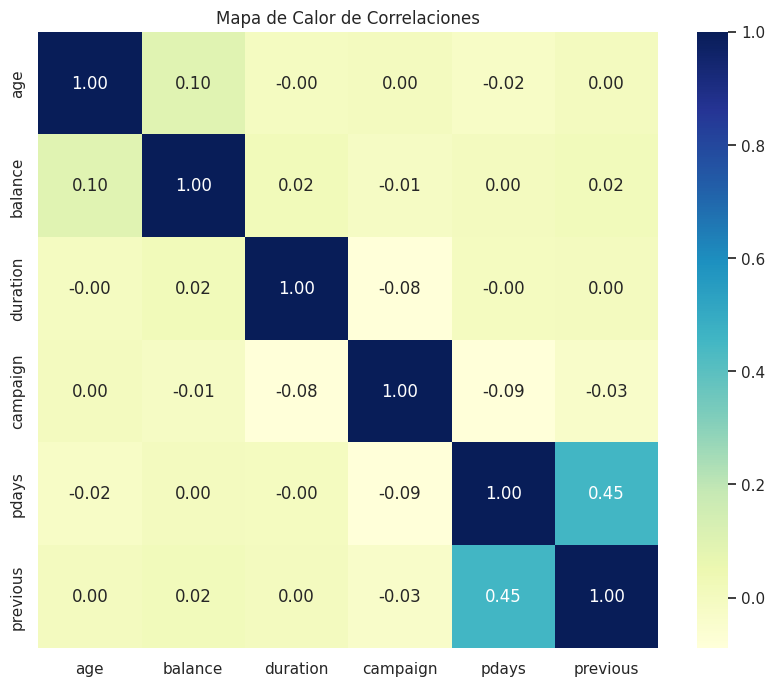

In [98]:
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='YlGnBu',fmt='.2f')
plt.title('Mapa de Calor de Correlaciones')
plt.show()

La mayoría de las variables numéricas presenta correlaciones bajas, lo que sugiere una baja multicolinealidad. La relación más relevante se observa entre pdays y previous (0.45), indicando que ambas están asociadas al historial de campañas anteriores.

El análisis exploratorio permitió identificar distribuciones asimétricas, presencia de valores extremos y un fuerte desbalance en la variable objetivo. La duración de la llamada destaca como una variable potencialmente predictiva de la suscripción al depósito. Asimismo, las correlaciones entre variables numéricas son generalmente bajas, lo que indica que cada característica aporta información complementaria para los modelos de clasificación que se desarrollarán posteriormente.

In [56]:
# 2.2. Estadísticas descriptivas
# Resumen general
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


In [57]:
df[numericas].mean()

,0
age,40.936210
balance,1362.272058
duration,258.163080
campaign,2.763841
pdays,40.197828
previous,0.580323


In [58]:
df[numericas].median()

,0
age,39.0
balance,448.0
duration,180.0
campaign,2.0
pdays,-1.0
previous,0.0


In [59]:
df.mode().head(1)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,32,blue-collar,married,secondary,no,0,yes,no,cellular,20,may,124,1,-1,0,failure,no


In [60]:
df[numericas].std()

,0
age,10.618762
balance,3044.765829
duration,257.527812
campaign,3.098021
pdays,100.128746
previous,2.303441


In [61]:
rango=df[numericas].max()-df[numericas].min()
rango

,0
age,77
balance,110146
duration,4918
campaign,62
pdays,872
previous,275


In [62]:
estadisticas=pd.DataFrame({'Media':df[numericas].mean(),'Mediana':df[numericas].median(),'Moda':df[numericas].mode().iloc[0],'Desv.Std':df[numericas].std(),'Min':df[numericas].min(),'Max':df[numericas].max(),'Rango':df[numericas].max()-df[numericas].min()})

estadisticas

,Media,Mediana,Moda,Desv.Std,Min,Max,Rango
age,40.936210,39.0,32,10.618762,18,95,77
balance,1362.272058,448.0,0,3044.765829,-8019,102127,110146
duration,258.163080,180.0,124,257.527812,0,4918,4918
campaign,2.763841,2.0,1,3.098021,1,63,62
pdays,40.197828,-1.0,-1,100.128746,-1,871,872
previous,0.580323,0.0,0,2.303441,0,275,275


**Análisis de las Variables**

**Edad (age)**

Edad promedio de los clientes: 40.9 años.

La mediana (39) es cercana a la media, indicando una distribución relativamente equilibrada.

La dispersión es moderada (10.6 años).

La mayoría de los clientes corresponde a adultos de mediana edad, concentrados principalmente entre los 30 y 50 años.

**Balance (balance)**

Media: 1362.

Mediana: 448.

Moda: 0.

Rango extremadamente amplio (110.146).

La gran diferencia entre media y mediana indica una fuerte asimetría positiva causada por clientes con balances excepcionalmente altos. Existen valores extremos importantes que aumentan considerablemente la media.

**Duración de la llamada (duration)**

Duración promedio: 258 segundos.

Mediana: 180 segundos.

Valor máximo: 4918 segundos.

La duración de las llamadas presenta una distribución sesgada hacia la derecha, con algunas conversaciones extraordinariamente largas.

**Número de contactos durante la campaña (campaign)**

Promedio de contactos: 2.76.

La mayoría de los clientes fue contactada una o dos veces.

Generalmente las campañas requieren pocos intentos de contacto para cada cliente.

**Días desde el contacto anterior (pdays)**

Mediana y moda iguales a -1.

El valor -1 indica que muchos clientes nunca habían sido contactados anteriormente.

La mayoría de los clientes no registra contactos previos con campañas anteriores, generando una distribución altamente asimétrica.

**Contactos previos (previous)**

Media: 0.58.

Mediana y moda: 0.

La mayoría de los clientes no había participado en campañas anteriores, aunque existen algunos casos aislados con numerosos contactos históricos.

El análisis descriptivo muestra que varias variables numéricas presentan distribuciones asimétricas y valores extremos, especialmente balance, duration, pdays y previous. Estas características sugieren la necesidad de aplicar técnicas de preprocesamiento y escalamiento antes de entrenar modelos predictivos. Además, la diferencia entre media y mediana en varias variables confirma la presencia de outliers y distribuciones no normales dentro del dataset.

**3. Implementación de Modelos:**

**3.1. Modelos de Clasificación:** Implementa modelos de Decision Tree y Support Vector Machine (SVM).

**3.2. Evaluación de Modelos:** Evalúa los modelos utilizando métricas como accuracy, precision, recall, y F1-score.

**3.3. Comparación de Rendimiento:** Compara los resultados de ambos modelos y discute cuál es el más adecuado para este dataset.


In [63]:
# 3.1. Modelos de Clasificación
# Variable objetivo
y=df['y'].map({'no':0,'yes': 1})

# Variables predictoras
X=df.drop('y',axis=1)

In [64]:
categoricas=X.select_dtypes(include='object').columns.tolist()
numericas=X.select_dtypes(exclude='object').columns.tolist()

print("Variables categóricas:", categoricas)
print("Variables numéricas:", numericas)

Variables categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Variables numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocesador=ColumnTransformer([('num',StandardScaler(),numericas),('cat',OneHotEncoder(handle_unknown='ignore'),categoricas)])

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape)
print(X_test.shape)

(36168, 16)
(9043, 16)


In [67]:
# Modelo 1: Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

pipeline_dt = Pipeline([('prep', preprocesador),('modelo', DecisionTreeClassifier(random_state=42,max_depth=5))])
pipeline_dt.fit(X_train, y_train)
y_pred_dt = pipeline_dt.predict(X_test)

In [68]:
# Modelo 2: SVM
from sklearn.svm import SVC

pipeline_svm=Pipeline([('prep',preprocesador),('modelo',SVC(kernel='rbf',probability=True,random_state=42))])
pipeline_svm.fit(X_train, y_train)
y_pred_svm = pipeline_svm.predict(X_test)

In [69]:
# 3.2. Evaluación de Modelos:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)

In [70]:
# Decision Tree
accuracy_dt=accuracy_score(y_test,y_pred_dt)
precision_dt=precision_score(y_test,y_pred_dt)
recall_dt=recall_score(y_test,y_pred_dt)
f1_dt=f1_score(y_test,y_pred_dt)

print("DECISION TREE")
print("Accuracy:", accuracy_dt)
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1:", f1_dt)

DECISION TREE
Accuracy: 0.8994802609753401
Precision: 0.6529774127310062
Recall: 0.3005671077504726
F1: 0.4116504854368932


In [71]:
# SVM
accuracy_svm=accuracy_score(y_test,y_pred_svm)
precision_svm=precision_score(y_test,y_pred_svm)
recall_svm=recall_score(y_test,y_pred_svm)
f1_svm=f1_score(y_test,y_pred_svm)

print("SVM")
print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1:", f1_svm)

SVM
Accuracy: 0.9030189096538759
Precision: 0.6806387225548902
Recall: 0.3223062381852552
F1: 0.4374599101988454


In [72]:
# Tabla Comparativa
resultados=pd.DataFrame({'Modelo':['Decision Tree','SVM'],'Accuracy':[accuracy_dt,accuracy_svm],'Precision':[precision_dt,precision_svm],'Recall':[recall_dt,recall_svm],'F1-Score':[f1_dt,f1_svm]})
resultados.sort_values(by='F1-Score',ascending=False)

,Modelo,Accuracy,Precision,Recall,F1-Score
1,SVM,0.903019,0.680639,0.322306,0.43746
0,Decision Tree,0.899480,0.652977,0.300567,0.41165


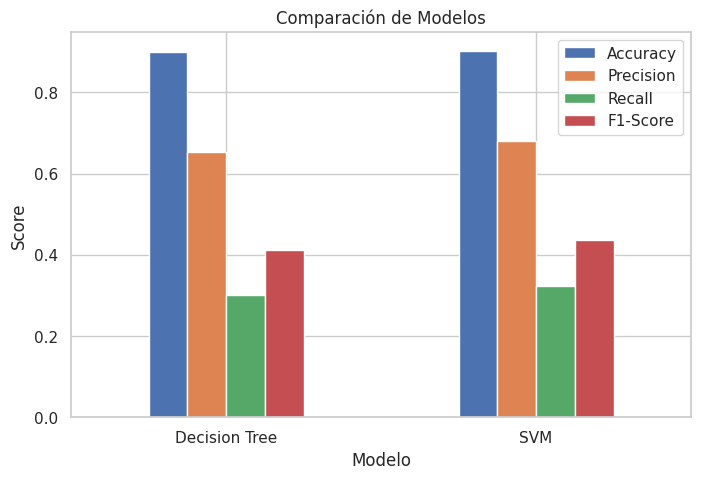

In [73]:
# Gráfico Comparativo
resultados.set_index('Modelo').plot(kind='bar',figsize=(8,5))
plt.title('Comparación de Modelos')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

El gráfico de comparación muestra que:

Las diferencias en Accuracy son pequeñas.

El modelo SVM mantiene una ventaja consistente en Precision, Recall y F1-Score.

Ninguno de los modelos presenta un Recall elevado, posiblemente debido al desbalance de clases observado anteriormente (88% "no" versus 12% "yes").

**3.3. Comparación de Rendimiento:**

**Análisis de Resultados**

Ambos modelos alcanzan una exactitud superior al 89%, lo que indica un buen desempeño general.

El modelo SVM obtuvo mejores resultados en todas las métricas evaluadas.

La precisión del SVM (68.1%) es superior a la del Árbol de Decisión (65.3%), lo que significa que comete menos falsos positivos al predecir clientes que contratarán un depósito.

El recall es relativamente bajo en ambos modelos, indicando que todavía existe dificultad para identificar a todos los clientes que efectivamente suscriben un depósito a plazo.

El F1-Score del SVM (43.7%) supera al del Árbol de Decisión (41.2%), mostrando un mejor equilibrio entre precisión y recall.

El modelo Support Vector Machine (SVM) presentó el mejor rendimiento global para este problema de clasificación bancaria, alcanzando una Accuracy de 90.3%, una Precision de 68.1% y un F1-Score de 43.7%. Aunque ambos modelos muestran dificultades para identificar todos los casos positivos debido al desbalance de clases del dataset, SVM supera consistentemente al Árbol de Decisión en todas las métricas evaluadas. Por esta razón, SVM se selecciona como el modelo más adecuado para predecir la suscripción de depósitos a plazo en este conjunto de datos.

Si bien los modelos alcanzaron una alta exactitud general, el recall obtenido fue relativamente bajo debido al desbalance de clases presente en el dataset. Esto indica que aún existe margen de mejora en la detección de clientes potencialmente interesados en contratar un depósito a plazo.

Los modelos desarrollados deben utilizarse como herramientas de apoyo a la decisión y no como único criterio para definir estrategias comerciales o financieras.

Nota: Uso de recursos externos. Durante el desarrollo de este análisis se utilizaron recursos de apoyo como apuntes de clases y trabajos Core, Resultados de Examen intento 1 cargado por Profesor Jesús, documentación oficial de Pandas, Matplotlib, Scikit-learn y consultas complementarias en ChatGPT para resolver dudas, depurar errores y mejorar la comprensión del código utilizado.

Referencias:

https://pandas.pydata.org/docs/

https://matplotlib.org/stable/index.html

https://scikit-learn.org/stable/

https://chat.openai.com/